In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('dataset/IT_equipment_business.xlsx', sheet_name= 'orders')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        331 non-null    object        
 1   order_date      331 non-null    datetime64[ns]
 2   customer_id     331 non-null    object        
 3   project_id      35 non-null     object        
 4   product_id      331 non-null    object        
 5   quantity        331 non-null    int64         
 6   unit_price      331 non-null    int64         
 7   cost_price      331 non-null    int64         
 8   discount        331 non-null    float64       
 9   revenue         331 non-null    int64         
 10  cost            331 non-null    int64         
 11  profit          331 non-null    int64         
 12  sales_chanel    331 non-null    object        
 13  payment_method  331 non-null    object        
 14  order_status    331 non-null    object        
 15  delive

In [3]:
print("Ngày đặt hàng sớm nhất:", df["order_date"].min())

print("Ngày đặt hàng muộn nhất:", df["order_date"].max())

print("Số mã đơn hàng khác nhau:", df["order_id"].nunique())

print("Số khách hàng phát sinh giao dịch:", df["customer_id"].nunique())

print("Số sản phẩm phát sinh giao dịch:", df["product_id"].nunique())

Ngày đặt hàng sớm nhất: 2023-01-01 00:00:00
Ngày đặt hàng muộn nhất: 2024-12-31 00:00:00
Số mã đơn hàng khác nhau: 326
Số khách hàng phát sinh giao dịch: 300
Số sản phẩm phát sinh giao dịch: 106


In [4]:
df.describe()

,order_date,quantity,unit_price,cost_price,discount,revenue,cost,profit,delivery_date
count,331,331.000000,3.310000e+02,3.310000e+02,331.000000,3.310000e+02,3.310000e+02,3.310000e+02,309
mean,2024-02-23 04:51:28.821752320,16.987915,7.725076e+06,6.538915e+06,0.028338,1.319470e+08,1.151194e+08,1.682758e+07,2024-02-09 10:10:29.126213632
min,2023-01-01 00:00:00,8.000000,4.000000e+06,3.287000e+06,0.000000,3.040000e+07,2.634400e+07,4.048000e+06,2023-01-06 00:00:00
25%,2023-10-02 00:00:00,12.000000,6.000000e+06,4.990000e+06,0.000000,7.697500e+07,6.703450e+07,9.615000e+06,2023-09-11 00:00:00
50%,2024-02-01 00:00:00,16.000000,8.000000e+06,6.619000e+06,0.030000,1.080000e+08,9.389600e+07,1.378800e+07,2024-01-10 00:00:00
75%,2024-09-29 00:00:00,21.000000,1.000000e+07,8.325000e+06,0.050000,1.616000e+08,1.415740e+08,2.028000e+07,2024-08-19 00:00:00
max,2024-12-31 00:00:00,44.000000,1.400000e+07,1.157600e+07,0.080000,5.852000e+08,5.093440e+08,7.585600e+07,2025-01-04 00:00:00
std,NaN,6.998691,2.487534e+06,2.076703e+06,0.021963,8.601345e+07,7.501609e+07,1.102146e+07,NaN


In [5]:
numeric_columns = [
    "quantity",
    "unit_price",
    "cost_price",
    "discount",
    "revenue",
    "cost",
    "profit"
]

descriptive_stats = df[
    numeric_columns
].describe().T

descriptive_stats["median"] = df[
    numeric_columns
].median()

descriptive_stats

,count,mean,std,min,25%,50%,75%,max,median
quantity,331.0,1.698792e+01,6.998691e+00,8.0,12.0,1.600000e+01,2.100000e+01,4.400000e+01,1.600000e+01
unit_price,331.0,7.725076e+06,2.487534e+06,4000000.0,6000000.0,8.000000e+06,1.000000e+07,1.400000e+07,8.000000e+06
cost_price,331.0,6.538915e+06,2.076703e+06,3287000.0,4990000.0,6.619000e+06,8.325000e+06,1.157600e+07,6.619000e+06
discount,331.0,2.833837e-02,2.196320e-02,0.0,0.0,3.000000e-02,5.000000e-02,8.000000e-02,3.000000e-02
revenue,331.0,1.319470e+08,8.601345e+07,30400000.0,76975000.0,1.080000e+08,1.616000e+08,5.852000e+08,1.080000e+08
cost,331.0,1.151194e+08,7.501609e+07,26344000.0,67034500.0,9.389600e+07,1.415740e+08,5.093440e+08,9.389600e+07
profit,331.0,1.682758e+07,1.102146e+07,4048000.0,9615000.0,1.378800e+07,2.028000e+07,7.585600e+07,1.378800e+07


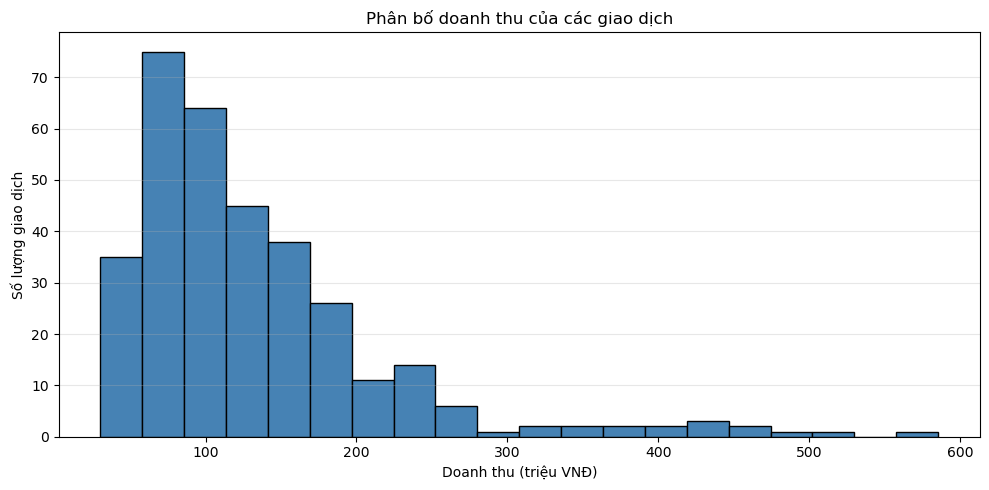

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["revenue"] / 1_000_000,
    bins=20,
    color="steelblue",
    edgecolor="black"
)

plt.title("Phân bố doanh thu của các giao dịch")
plt.xlabel("Doanh thu (triệu VNĐ)")
plt.ylabel("Số lượng giao dịch")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

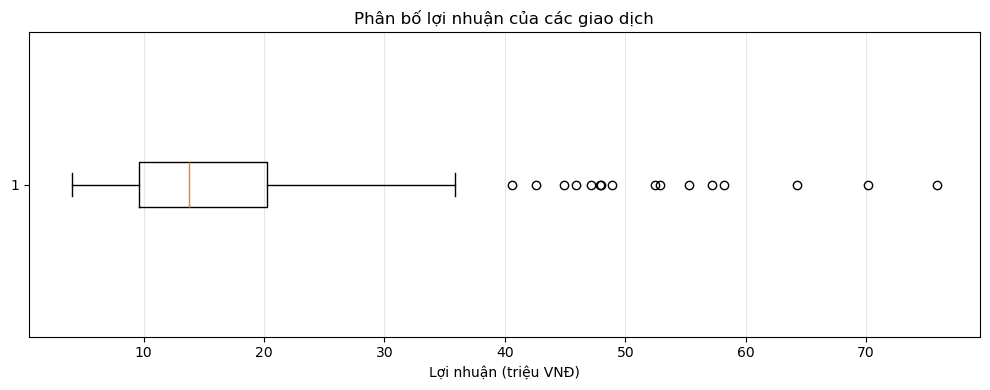

In [7]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    df["profit"] / 1_000_000,
    vert=False
)

plt.title("Phân bố lợi nhuận của các giao dịch")
plt.xlabel("Lợi nhuận (triệu VNĐ)")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

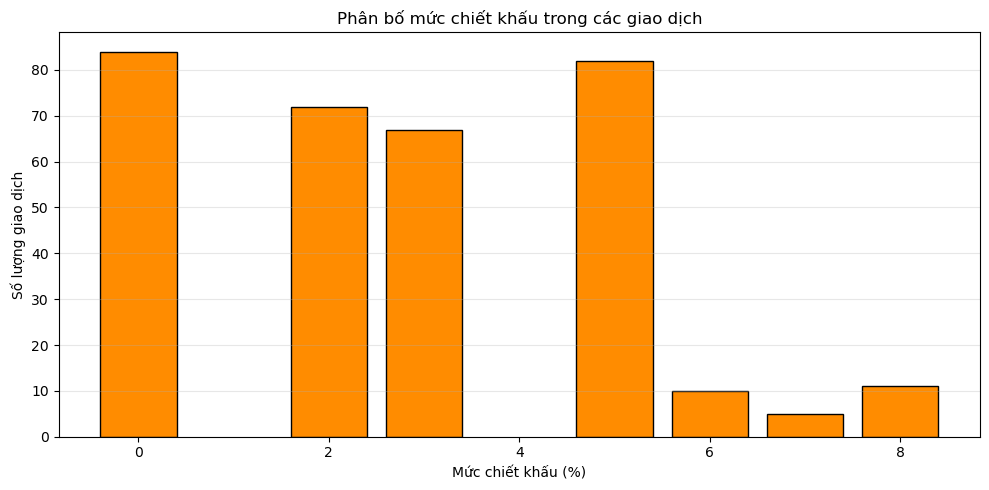

In [8]:
discount_counts = (
    df["discount"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    discount_counts.index * 100,
    discount_counts.values,
    color="darkorange",
    edgecolor="black"
)

plt.title("Phân bố mức chiết khấu trong các giao dịch")
plt.xlabel("Mức chiết khấu (%)")
plt.ylabel("Số lượng giao dịch")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
correlation_columns = [
    "discount",
    "revenue",
    "cost",
    "profit"
]

correlation_matrix = df[
    correlation_columns
].corr(method="pearson")

correlation_matrix.round(2)

,discount,revenue,cost,profit
discount,1.00,0.37,0.37,0.38
revenue,0.37,1.00,1.00,1.00
cost,0.37,1.00,1.00,1.00
profit,0.38,1.00,1.00,1.00


In [19]:
correlation_columns = [
    "discount",
    "profit"
]

correlation_matrix = df[
    correlation_columns
].corr(method="pearson")

correlation_matrix.round(2)

,discount,profit
discount,1.00,0.38
profit,0.38,1.00


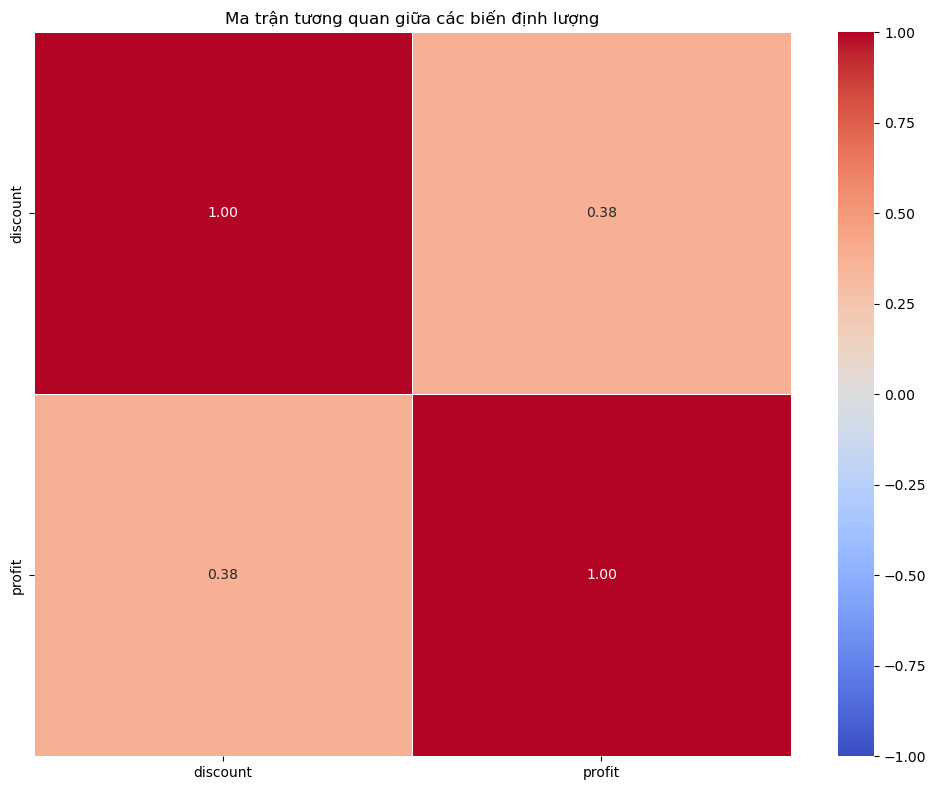

In [21]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Ma trận tương quan giữa các biến định lượng")
plt.tight_layout()
plt.show()

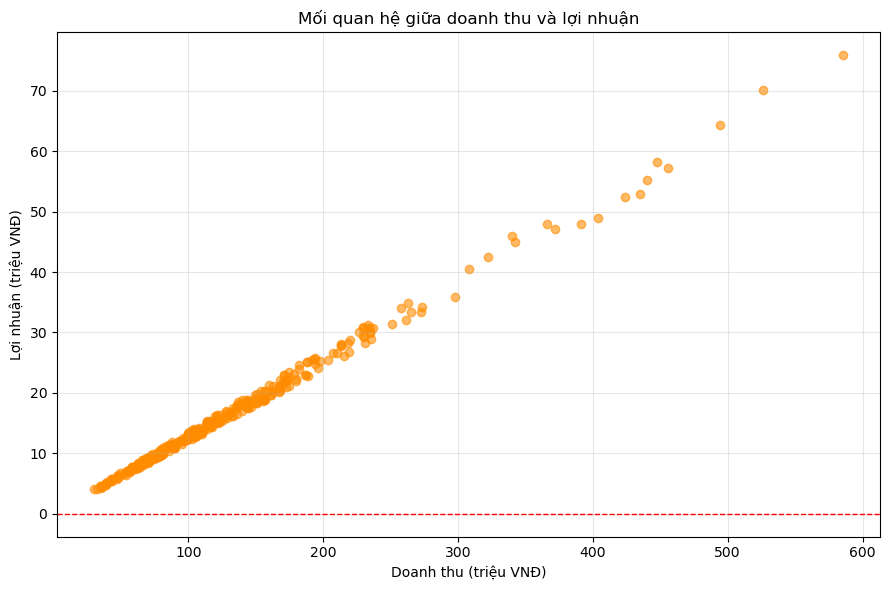

In [23]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["revenue"] / 1_000_000,
    df["profit"] / 1_000_000,
    alpha=0.6,
    color="darkorange"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1
)

plt.title("Mối quan hệ giữa doanh thu và lợi nhuận")
plt.xlabel("Doanh thu (triệu VNĐ)")
plt.ylabel("Lợi nhuận (triệu VNĐ)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
